In [12]:
import pandas as pd
import numpy as np
import importlib

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
from sklearn.metrics import silhouette_score

import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt

import utility_functions as uf

In [31]:
year = 1990
mode = "collaborative_"

In [32]:
df_cs = pd.read_csv(uf.PATH+f"df_country_subfield/{mode}{year}.csv", index_col=0)
df_prob = df_cs.div(df_cs.sum(axis=1), axis=0)

In [33]:
df_prob

,1100,1102,1103,1104,1105,1106,1107,1108,1109,1110,...,3600,3603,3604,3605,3607,3609,3611,3612,3614,3616
country,,,,,,,,,,,,,,,,,,,,,
AE,NaN,0.083333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.055556,0.027778,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
VN,NaN,NaN,NaN,0.012500,NaN,0.01250,NaN,NaN,NaN,0.062500,...,0.037500,NaN,NaN,0.0125,NaN,NaN,NaN,NaN,NaN,NaN
YE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ZA,0.006135,0.006135,0.006135,0.003067,0.015337,0.01227,0.003067,NaN,0.009202,0.018405,...,0.009202,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.003067,NaN


In [34]:
importlib.reload(uf)

<module 'utility_functions' from '/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py'>

In [ ]:
df_dist = uf.get_jaccard_distances(df_prob)
df_dist_turn = uf.get_jacca

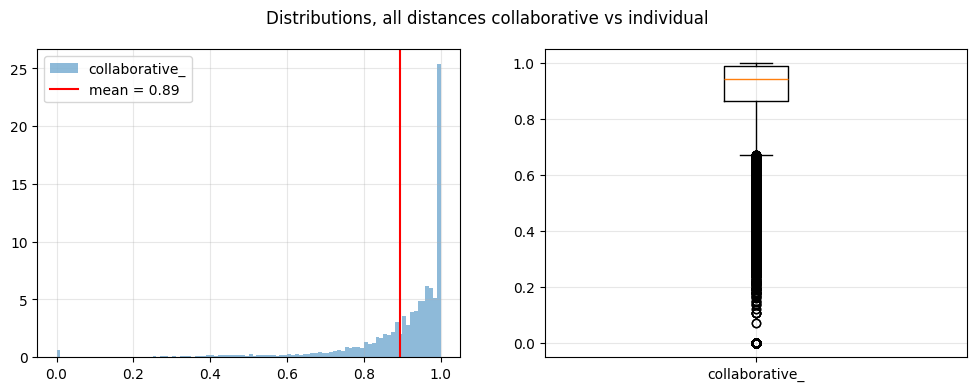

In [36]:
fig, (ax1, ax2) =plt.subplots(ncols=2, nrows=1, figsize=(12, 4))

data1 = df_dist.values.flatten()
data1 = data1[~np.isnan(data1)]

ax1.hist(data1, bins=100, alpha=0.5, label=mode, density=True)
ax1.axvline(data1.mean(), color="red", label=f"mean = {round(data1.mean(), 2)}")
ax1.legend()
ax1.grid(alpha=0.3)
# plt.show()

plt.subplot(1, 2, 2)

ax2.boxplot([data1])
ax2.set_xticks([1], [mode])
ax2.grid(alpha=0.3)

plt.suptitle("Distributions, all distances collaborative vs individual")
plt.show()

In [37]:
uf.plotly_heatmap(
    df_dist,
    x_labels=df_dist.columns,
    y_labels=df_dist.index,
    z_min=0, z_max=1,
    colorscale="non-symmetrical",
    x_type="country",
    y_type="country",
    title=f"Distance between countries, {mode[:-1]}, {year}",
)

In [38]:
from sklearn.cluster import AgglomerativeClustering

D = df_dist.values

model = AgglomerativeClustering(n_clusters=20, metric='precomputed', linkage='average')

labels = model.fit_predict(D)

score = silhouette_score(D, labels, metric="precomputed")
score

np.float64(0.1185412375136094)

In [39]:
labels

array([ 0, 14,  2,  0,  6,  0,  0,  0,  0,  0, 11,  0,  0,  1,  0,  1,  4,
        4,  2,  1,  8,  0,  2,  0,  0,  1,  4,  0,  0,  0,  0,  0,  0,  0,
        0,  7,  0,  0,  3,  0,  8,  0, 14,  0,  0,  0,  0,  0,  8,  4,  0,
        7,  0,  0,  5,  0,  9,  8,  6,  2,  0, 14,  2, 13,  0,  4,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  3, 15,  0,  0,  0,
        7,  0,  6,  0,  8,  4,  0,  9,  0, 10,  0, 10,  5,  8,  0,  2,  9,
        0,  8,  2, 16,  4,  2,  4,  0,  0,  2,  8,  0,  0,  7,  0,  0,  0,
        0,  6,  0,  0,  8,  0,  0,  0,  0,  0, 19,  0,  0,  0,  0,  0,  0,
        0, 16,  0,  8, 18,  0,  0,  0,  0,  0,  7,  2,  4,  0,  8, 17,  0,
       18,  2,  0,  0, 12,  0,  0,  3,  0,  0,  0,  0,  0,  0,  0,  0,  3,
        2,  0,  0,  0,  0,  0])

In [16]:
from sklearn.cluster import DBSCAN

D = df_dist.values

model = DBSCAN(eps=0.1, min_samples=2, metric='precomputed')
labels = model.fit_predict(D)
score = silhouette_score(D, labels, metric="precomputed")
score

np.float64(0.07487771828795184)

In [19]:
# Example: distance matrix (symmetric, zeros on diagonal)
D = df_dist.values

# Convert to condensed form (required by linkage)
condensed_D = squareform(D)

# Perform hierarchical clustering
# method can be: 'single', 'complete', 'average', 'ward'
Z = linkage(condensed_D, method='average')

labels = fcluster(Z, t=0.1, criterion='distance')
order = np.argsort(labels)

score = silhouette_score(D, labels, metric="precomputed")
score

np.float64(0.0761100305816611)

In [40]:
df_map = (
    df_dist
    .merge(uf.df_country[["alpha-2", "alpha-3", "name", "region", "sub-region"]], left_index=True, right_on="alpha-2", how="left")
    [["alpha-2", "alpha-3", "name", "sub-region", "region"]]
    .assign(cluster=labels,
            cluster_str = lambda df: df["cluster"].astype(str))
    .rename(columns={"alpha-3": "country", "alpha-2": "country2"})
)
df_map.sample(5)

,country2,country,name,sub-region,region,cluster,cluster_str
45,CN,CHN,China,Eastern Asia,Asia,0,0
214,SE,SWE,Sweden,Northern Europe,Europe,0,0
235,US,USA,United States of America,Northern America,Americas,0,0
100,HK,HKG,Hong Kong,Eastern Asia,Asia,0,0
126,LR,LBR,Liberia,Sub-Saharan Africa,Africa,8,8


(<Figure size 1200x600 with 2 Axes>, <Axes: title={'center': ' '}>)

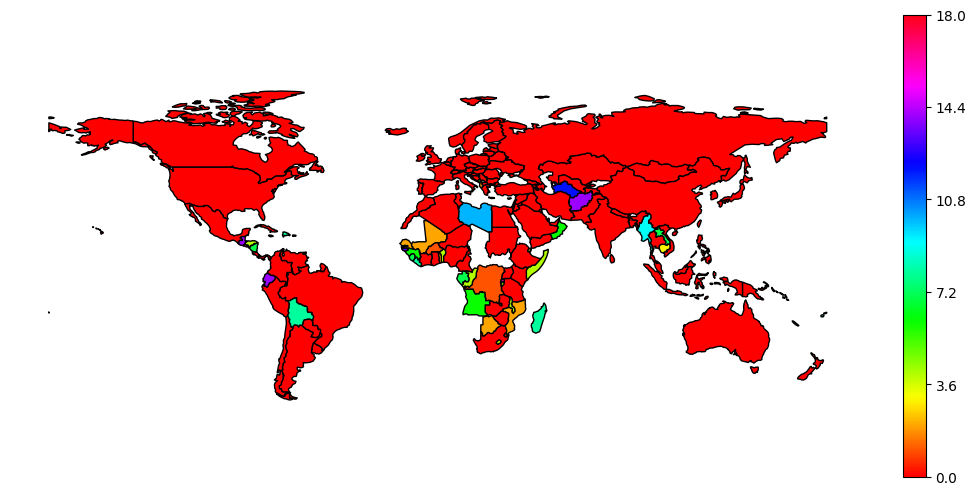

In [41]:
uf.plot_map_continuous(df_map, "cluster", country_column="country")